In [1]:
# Part 1 — Exploratory Data Analysis:
# Dataset: California Housing (1990 Census) | 20,640 rows · 10 columns
# Goal: Understanding the data's structure, distributions, relationships, and quality issues before modelling.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

# 1. Loading the Data
df = pd.read_csv("data/housing_raw.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# 2. Dataset Overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [3]:
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
longitude,20640.00,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.00,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.00,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.00,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.00,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.00,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.00,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.00,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.00,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


In [4]:
# 3. Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing values across ALL columns:")
display(missing_df)

cols_over_20 = missing_df[missing_df["Missing %"] > 20]
print(f"Columns exceeding 20% missing: {list(cols_over_20.index) if len(cols_over_20) else 'None'}")

missing_only = missing_df[missing_df["Missing Count"] > 0]
display(missing_only)

Missing values across ALL columns:


,Missing Count,Missing %
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
total_bedrooms,207,1.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


Columns exceeding 20% missing: None


,Missing Count,Missing %
total_bedrooms,207,1.0


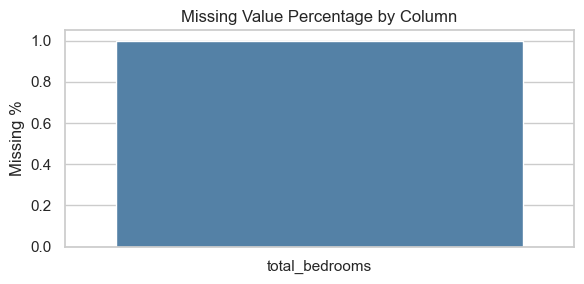

In [5]:
plt.figure(figsize=(6, 3))
sns.barplot(x=missing_only.index, y="Missing %", data=missing_only, color="steelblue")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing %")
plt.xlabel("")
plt.tight_layout()
plt.show()

Only `total_bedrooms` has missing values (207 rows, 1.0%) — well below the 20% threshold,
so this column will be imputed in preprocessing rather than dropped.
 No other column has any missing values.

In [6]:
# 4. Duplicate Rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [7]:
# 5. Skewness Analysis
numeric_cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population",
    "households", "median_income", "median_house_value"
]

skew_vals = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("Skewness of numeric columns (sorted by absolute value):")
display(skew_vals)

most_skewed_col = skew_vals.index[0]
print(f"Most skewed column: {most_skewed_col}  (skew = {skew_vals.iloc[0]:.2f})")

Skewness of numeric columns (sorted by absolute value):


population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
median_house_value    0.977763
latitude              0.465953
longitude            -0.297801
housing_median_age    0.060331
dtype: float64

Most skewed column: population  (skew = 4.94)


`population` is the most skewed numeric column (skew ≈ 4.94), and it is positively skewed.
A small number of densely populated block groups create a long right tail, while most block groups have a modest population.
`total_rooms`, `total_bedrooms`, and `households` show the same pattern for the same underlying reason.

Consequence for imputation:
For a positively skewed column, the mean is pulled upward by rare extreme values.
The median is more representative and is the safer choice for missing-value imputation.

In [8]:
# 6. Outlier Detection (IQR Method)
print("Applying the IQR method to two numeric columns: 'total_rooms' and 'median_house_value'.")

for col in ["total_rooms", "median_house_value"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    print(f"--- {col} ---")
    print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"Lower bound={lower_bound:.2f}  Upper bound={upper_bound:.2f}")
    print(f"Outlier rows: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
    print()

Applying the IQR method to two numeric columns: 'total_rooms' and 'median_house_value'.
--- total_rooms ---
Q1=1447.75  Q3=3148.00  IQR=1700.25
Lower bound=-1102.62  Upper bound=5698.38
Outlier rows: 1287 (6.2%)

--- median_house_value ---
Q1=119600.00  Q3=264725.00  IQR=145125.00
Lower bound=-98087.50  Upper bound=482412.50
Outlier rows: 1071 (5.2%)



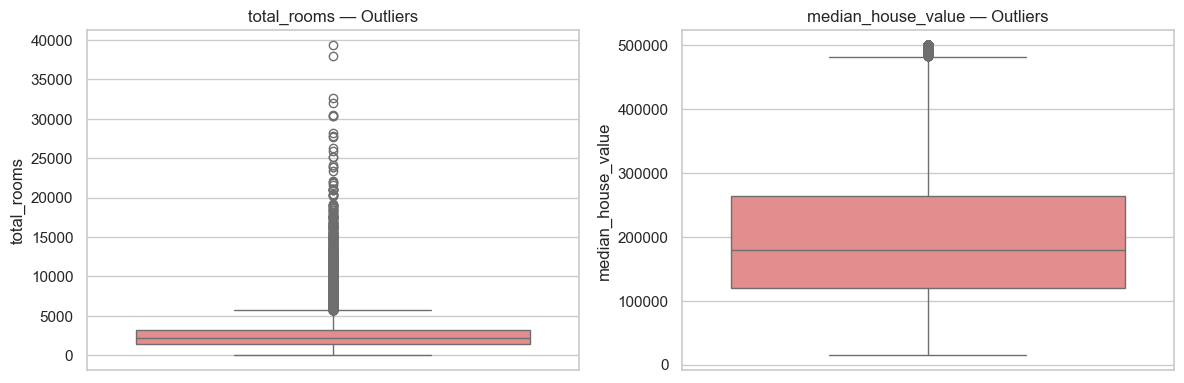

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["total_rooms"], ax=axes[0], color="lightcoral")
axes[0].set_title("total_rooms — Outliers")
sns.boxplot(y=df["median_house_value"], ax=axes[1], color="lightcoral")
axes[1].set_title("median_house_value — Outliers")
plt.tight_layout()
plt.show()

`total_rooms` outliers represent unusually large block groups and are plausible, so they are retained.
`median_house_value` outliers mostly reflect the dataset's top-coding ceiling at $500,001, not a measurement error.

Decision for Part 2:
Outliers will be retained, not dropped.
Count-like features can be normalized later through ratio features, and the capped target values can be flagged if needed.

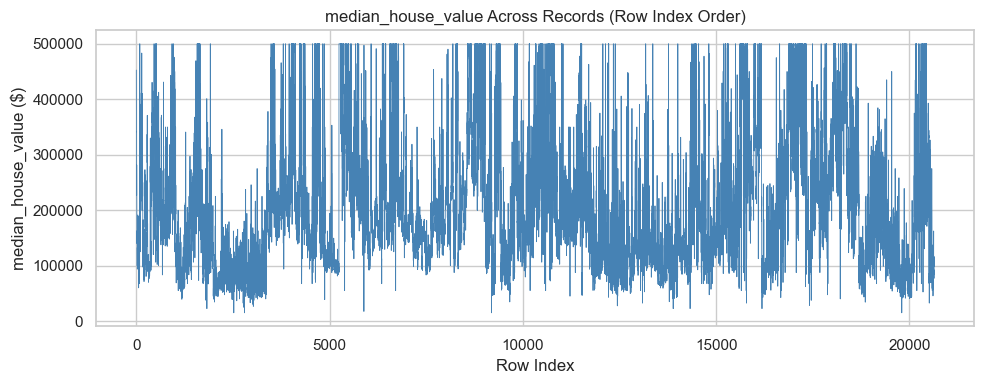

In [10]:
#  Visualizations

# Line plot — median_house_value across records, sorted by row index
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["median_house_value"], linewidth=0.6, color="steelblue")
plt.title("median_house_value Across Records (Row Index Order)")
plt.xlabel("Row Index")
plt.ylabel("median_house_value ($)")
plt.tight_layout()
plt.show()

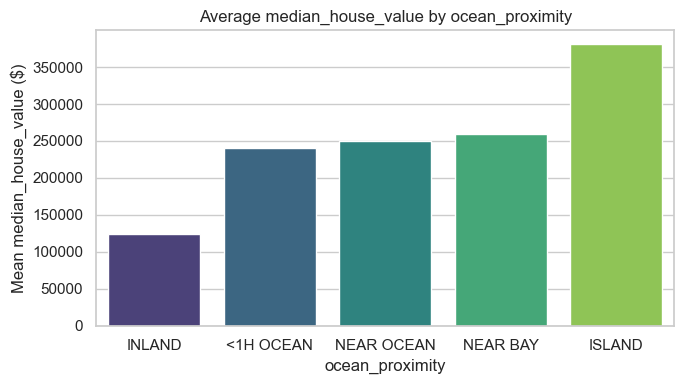

In [11]:
# 7b. Bar chart — mean median_house_value by ocean_proximity
mean_by_prox = df.groupby("ocean_proximity")["median_house_value"].mean().sort_values()

plt.figure(figsize=(7, 4))
sns.barplot(x=mean_by_prox.index, y=mean_by_prox.values, hue=mean_by_prox.index,
            palette="viridis", legend=False)
plt.title("Average median_house_value by ocean_proximity")
plt.xlabel("ocean_proximity")
plt.ylabel("Mean median_house_value ($)")
plt.tight_layout()
plt.show()

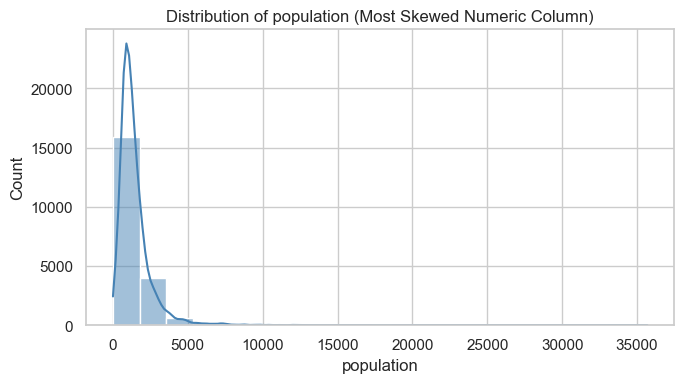

In [12]:
# 7c. Histogram — distribution of the most skewed column (population)
plt.figure(figsize=(7, 4))
sns.histplot(df["population"], bins=20, color="steelblue", kde=True)
plt.title("Distribution of population (Most Skewed Numeric Column)")
plt.xlabel("population")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Shape : strongly right-skewed — most block groups have a modest population, with a long tail toward a few very large ones.

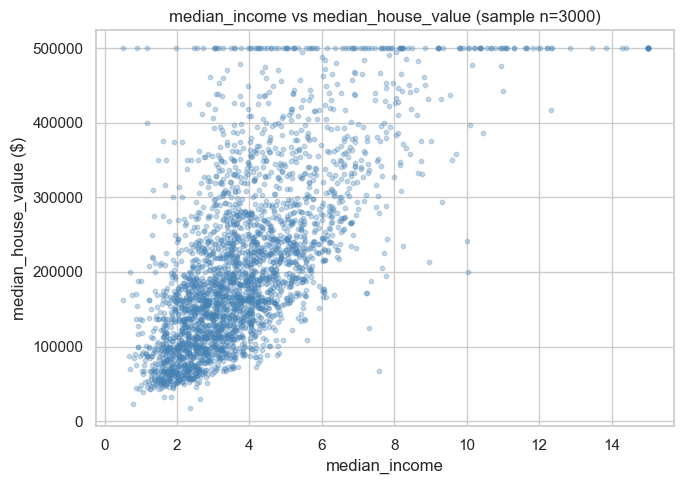

In [13]:
# 7d. Scatter plot — median_income vs median_house_value (expected to be correlated)
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(sample["median_income"], sample["median_house_value"], alpha=0.3, s=10, color="steelblue")
plt.title("median_income vs median_house_value (sample n=3000)")
plt.xlabel("median_income")
plt.ylabel("median_house_value ($)")
plt.tight_layout()
plt.show()

Interpretation:
- A clear positive relationship — block groups with higher median income tend to have higher median house values.
- The relationship is moderately strong and roughly linear for most of the range, but it flattens near the top due to the $500,001 reporting cap.

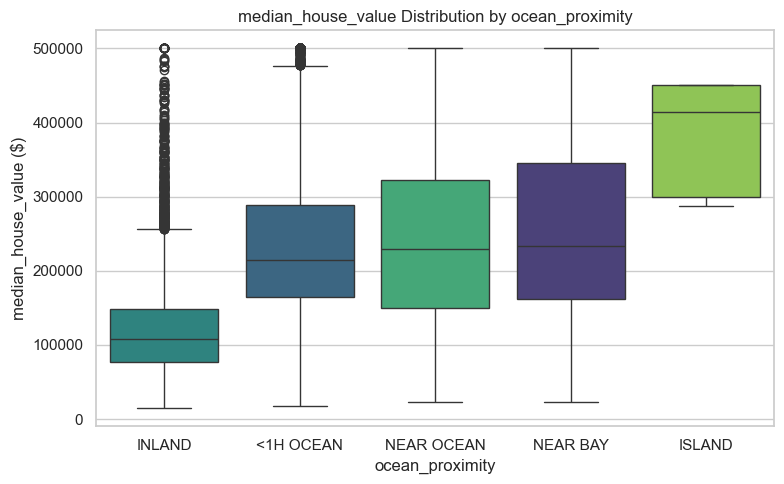

In [14]:
# 7e. Box plot — median_house_value split by ocean_proximity
plt.figure(figsize=(8, 5))
order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values().index
sns.boxplot(x="ocean_proximity", y="median_house_value", data=df, order=order, palette="viridis",
            hue="ocean_proximity", legend=False)
plt.title("median_house_value Distribution by ocean_proximity")
plt.xlabel("ocean_proximity")
plt.ylabel("median_house_value ($)")
plt.tight_layout()
plt.show()

Interpretation:
- `INLAND` has both the lowest median and a comparatively tight spread.
- `NEAR BAY` and `NEAR OCEAN` show higher medians and wider spreads.
- `ISLAND` sits highest but has very few rows, so it is not statistically strong.

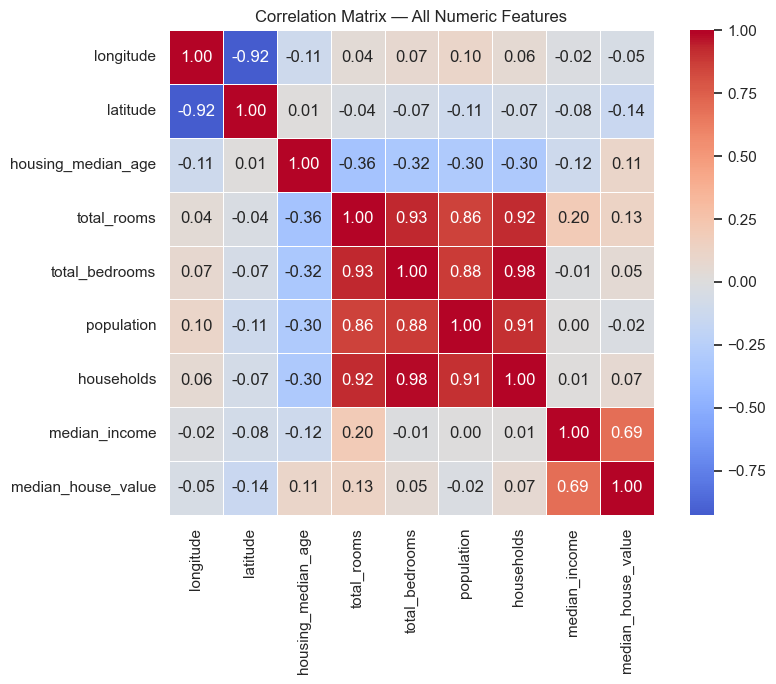

In [15]:
# Correlation Analysis
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Correlation Matrix — All Numeric Features")
plt.tight_layout()
plt.show()

In [16]:
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1].sort_values(ascending=False)

top_pair = corr_pairs.index[0]
print(f"Highest absolute correlation pair: {top_pair} -> r = {corr.loc[top_pair]:.3f}")

Highest absolute correlation pair: ('households', 'total_bedrooms') -> r = 0.980


Highest correlation pair: `total_rooms` & `households`.
- This is likely because both are raw counts that scale with block-group size.
- A third variable such as land area or population density could explain both.
- So this correlation does not necessarily imply causality.

In [17]:
pearson_matrix = df[numeric_cols].corr()
spearman_matrix = df[numeric_cols].corr(method="spearman")

diff_matrix = (spearman_matrix - pearson_matrix).abs()
diff_pairs = diff_matrix.unstack()
diff_pairs = diff_pairs[diff_pairs < 1].sort_values(ascending=False)

print("Pearson matrix:")
display(pearson_matrix.round(3))

print("\nSpearman matrix:")
display(spearman_matrix.round(3))

print("\nTop 3 pairs by |Spearman - Pearson|:")
display(diff_pairs.head(3))

Pearson matrix:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000,-0.925,-0.108,0.045,0.070,0.100,0.055,-0.015,-0.046
latitude,-0.925,1.000,0.011,-0.036,-0.067,-0.109,-0.071,-0.080,-0.144
housing_median_age,-0.108,0.011,1.000,-0.361,-0.320,-0.296,-0.303,-0.119,0.106
total_rooms,0.045,-0.036,-0.361,1.000,0.930,0.857,0.918,0.198,0.134
total_bedrooms,0.070,-0.067,-0.320,0.930,1.000,0.878,0.980,-0.008,0.050
population,0.100,-0.109,-0.296,0.857,0.878,1.000,0.907,0.005,-0.025
households,0.055,-0.071,-0.303,0.918,0.980,0.907,1.000,0.013,0.066
median_income,-0.015,-0.080,-0.119,0.198,-0.008,0.005,0.013,1.000,0.688
median_house_value,-0.046,-0.144,0.106,0.134,0.050,-0.025,0.066,0.688,1.000



Spearman matrix:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000,-0.879,-0.151,0.040,0.064,0.124,0.060,-0.010,-0.070
latitude,-0.879,1.000,0.032,-0.018,-0.057,-0.124,-0.074,-0.088,-0.166
housing_median_age,-0.151,0.032,1.000,-0.357,-0.307,-0.284,-0.282,-0.147,0.075
total_rooms,0.040,-0.018,-0.357,1.000,0.915,0.816,0.907,0.271,0.206
total_bedrooms,0.064,-0.057,-0.307,0.915,1.000,0.871,0.976,-0.006,0.086
population,0.124,-0.124,-0.284,0.816,0.871,1.000,0.904,0.006,0.004
households,0.060,-0.074,-0.282,0.907,0.976,0.904,1.000,0.030,0.113
median_income,-0.010,-0.088,-0.147,0.271,-0.006,0.006,0.030,1.000,0.677
median_house_value,-0.070,-0.166,0.075,0.206,0.086,0.004,0.113,0.677,1.000



Top 3 pairs by |Spearman - Pearson|:


total_rooms         median_income    0.073271
median_income       total_rooms      0.073271
median_house_value  total_rooms      0.071799
dtype: float64

For Part 2 feature selection, Spearman is the safer guide because the data is skewed and Spearman is more robust to non-linearity.

In [18]:
# 10. Grouped Aggregation
grouped_stats = df.groupby("ocean_proximity")["median_house_value"].agg(["mean", "std", "count"]).sort_values("mean")
display(grouped_stats)

,mean,std,count
ocean_proximity,,,
INLAND,124805.392001,70007.908494,6551
<1H OCEAN,240084.285464,106124.292213,9136
NEAR OCEAN,249433.977427,122477.145927,2658
NEAR BAY,259212.311790,122818.537064,2290
ISLAND,380440.000000,80559.561816,5


(a) Highest mean and highest std:
- `ISLAND` has the highest mean, but it has only 5 rows, so that estimate is not reliable.
- Among well-represented groups, `NEAR BAY` has the highest mean and the highest standard deviation.

(b) High within-group standard deviation is a concern because the category alone is not enough to predict house value reliably.

(c) Ratio of highest to lowest reliable group mean:
- It is a bit above 2x, so the categorical feature does carry predictive signal.

In [19]:
# Saving Cleaned Dataset
df.to_csv("data/housing_clean.csv", index=False)
print("Saved housing_clean.csv")

Saved housing_clean.csv


## EDA Summary

| Step | Action |
|---|---|
| 1 | Loaded `housing_raw.csv` |
| 2 | Reviewed dataset structure and overview (`.info()`, `.describe()`) |
| 3 | Checked missing values across all columns |
| 4 | Checked for duplicate rows |
| 5 | Analyzed skewness of numeric columns |
| 6 | Detected outliers using the IQR method |
| 7 | Visualized distributions and relationships (line, bar, histogram, scatter, box plots) |
| 8 | Compared Pearson vs. Spearman correlations |
| 9 | Performed grouped aggregation by `ocean_proximity` |
| 10 | Saved `housing_clean.csv` |

### Key Findings

- `total_bedrooms` is the only column with missing values (1.0%) — flagged for imputation in preprocessing.
- `population`, `total_rooms`, `total_bedrooms`, and `households` are right-skewed — median favored over mean for imputation.
- Outliers in `total_rooms` and `median_house_value` are retained (plausible values / top-coding artifact, not errors).
- `median_income` shows a clear positive relationship with `median_house_value`.
- `total_rooms` and `households` are the most correlated feature pair.
- Spearman preferred over Pearson for feature selection given the skewed data.

### Short Note

This step establishes data quality and structure — confirming no severe missingness, identifying skew and outlier handling decisions, and surfacing key relationships — before any cleaning or feature engineering is applied in `preprocessing1.ipynb`.